In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.preprocessing import *

In [2]:
# Abrir archivo raw_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                17986 non-null  object 
 1   Close               17986 non-null  float64
 2   Ticker              17986 non-null  object 
 3   Monthly_Return      17514 non-null  float64
 4   Monthly_Variance    17514 non-null  float64
 5   Market_Covariance   17514 non-null  float64
 6   MarketCap           17935 non-null  float64
 7   EnterpriseValue     17935 non-null  float64
 8   PE_Trailing         17896 non-null  float64
 9   EnterpriseToEbitda  17935 non-null  float64
 10  PriceToBook         17896 non-null  float64
 11  operatingMargins    17986 non-null  float64
 12  profitMargins       17947 non-null  float64
 13  returnOnEquity      17908 non-null  float64
 14  ReturnOnAssets      17947 non-null  float64
 15  debtToEquity        17947 non-null  float64
 16  curr

# Missing Values

In [3]:
# Imputar multivariable con IterativeImputer sobre continuas
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

df_cont = df.select_dtypes(include='number')

df_cont_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_cont_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Close               17986 non-null  float64
 1   Monthly_Return      17986 non-null  float64
 2   Monthly_Variance    17986 non-null  float64
 3   Market_Covariance   17986 non-null  float64
 4   MarketCap           17986 non-null  float64
 5   EnterpriseValue     17986 non-null  float64
 6   PE_Trailing         17986 non-null  float64
 7   EnterpriseToEbitda  17986 non-null  float64
 8   PriceToBook         17986 non-null  float64
 9   operatingMargins    17986 non-null  float64
 10  profitMargins       17986 non-null  float64
 11  returnOnEquity      17986 non-null  float64
 12  ReturnOnAssets      17986 non-null  float64
 13  debtToEquity        17986 non-null  float64
 14  currentRatio        17986 non-null  float64
 15  Revenue_YoY         17986 non-null  float64
 16  Reve

In [4]:
df_imputed = pd.concat([df_cont_imputed, df.select_dtypes(exclude='number')], axis=1)

In [5]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Close               17986 non-null  float64
 1   Monthly_Return      17986 non-null  float64
 2   Monthly_Variance    17986 non-null  float64
 3   Market_Covariance   17986 non-null  float64
 4   MarketCap           17986 non-null  float64
 5   EnterpriseValue     17986 non-null  float64
 6   PE_Trailing         17986 non-null  float64
 7   EnterpriseToEbitda  17986 non-null  float64
 8   PriceToBook         17986 non-null  float64
 9   operatingMargins    17986 non-null  float64
 10  profitMargins       17986 non-null  float64
 11  returnOnEquity      17986 non-null  float64
 12  ReturnOnAssets      17986 non-null  float64
 13  debtToEquity        17986 non-null  float64
 14  currentRatio        17986 non-null  float64
 15  Revenue_YoY         17986 non-null  float64
 16  Reve

# Transformaciones

In [6]:
# Se calculan tamaños relativos
df_transformed = calcular_relative_size(df_imputed)

In [7]:
# Se expresan MarketCap y EnterpriseValue en billions
df_transformed["MarketCap"] = df_transformed["MarketCap"] / 10**9
df_transformed["EnterpriseValue"] = df_transformed["EnterpriseValue"] / 10**9

In [8]:
# Distribucion de variables continuas
df_transformed.describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
Close,17986.0,1.966437e+02,4.113543e+02,1.388000e+00,6.279070e+01,1.167374e+02,2.162691e+02,9.811800e+03
Monthly_Return,17986.0,1.450000e-02,9.500000e-02,-5.197000e-01,-3.970000e-02,1.170000e-02,6.120000e-02,1.427500e+00
Monthly_Variance,17986.0,8.800000e-03,1.380000e-02,-4.300000e-03,3.600000e-03,6.000000e-03,9.800000e-03,3.652000e-01
Market_Covariance,17986.0,1.600000e-03,1.500000e-03,-4.000000e-03,6.000000e-04,1.400000e-03,2.400000e-03,1.700000e-02
MarketCap,17986.0,1.080742e+02,3.488033e+02,6.997000e-01,1.825030e+01,3.515460e+01,7.721190e+01,5.172682e+03
EnterpriseValue,17986.0,1.201566e+02,3.532242e+02,3.164300e+00,2.285360e+01,4.388860e+01,9.135090e+01,5.173118e+03
PE_Trailing,17986.0,-1.534680e+01,1.982594e+03,-1.012030e+05,1.542520e+01,2.420090e+01,3.625920e+01,5.658647e+03
EnterpriseToEbitda,17986.0,2.267630e+01,9.082060e+01,-1.813325e+03,1.108420e+01,1.579440e+01,2.201740e+01,3.204700e+03
PriceToBook,17986.0,6.934600e+00,5.262330e+01,-1.113182e+03,1.880000e+00,3.763800e+00,8.130200e+00,1.354423e+03
operatingMargins,17986.0,1.910000e-01,1.513000e-01,-1.599400e+00,1.065000e-01,1.775000e-01,2.613000e-01,9.260000e-01


In [9]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew()

Close                 13.164410
Monthly_Return         1.541061
Monthly_Variance      12.127444
Market_Covariance      1.355800
MarketCap              8.282180
EnterpriseValue        8.143866
PE_Trailing          -39.412138
EnterpriseToEbitda    13.539830
PriceToBook            6.920873
operatingMargins      -0.439499
profitMargins         -1.907488
returnOnEquity         0.732737
ReturnOnAssets         0.711877
debtToEquity          -4.322232
currentRatio           6.739266
Revenue_YoY            3.991783
Revenue_QoQ            8.369238
EBITDA_YoY           -13.445745
EBITDA_QoQ           -25.422981
FCF_YoY               25.386196
FCF_QoQ               46.873638
Capex_YoY            -35.890451
Capex_QoQ            -73.223879
NetDebt_to_EBITDA      5.970072
FCF_to_EBITDA         13.963776
Capex_to_Revenue       2.843378
TotalAssets            3.689578
TotalRevenue           5.104912
TotalEquity            5.839592
RelativeAssets        47.723902
RelativeRevenue       33.797826
Relative

Cont


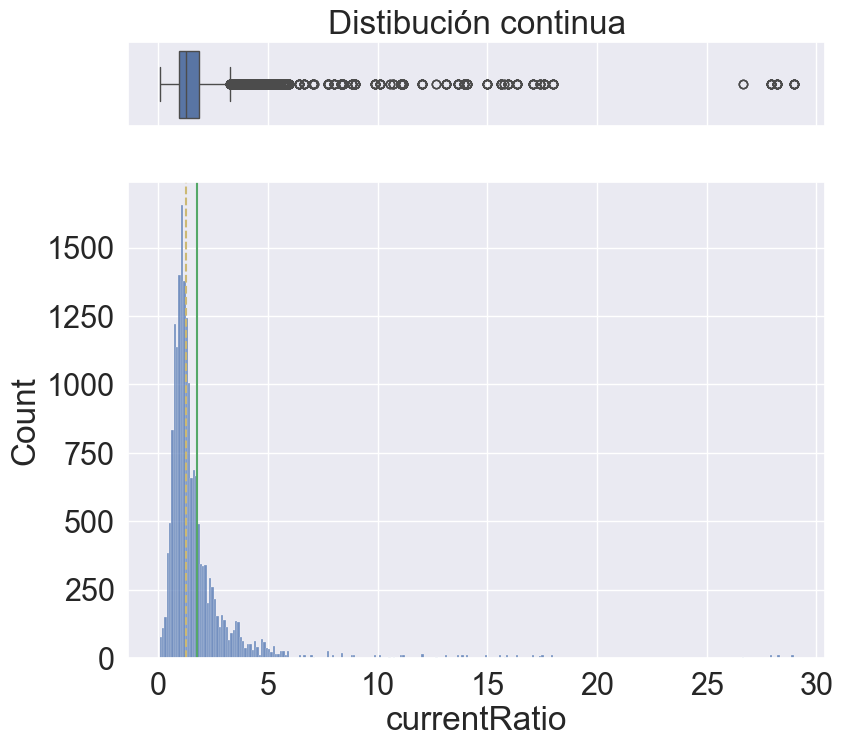

In [10]:
# Graficar
columna_a_graficar = 'currentRatio' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [11]:
# Transformacion yeo-johnson sobre ratios de valuación
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['returnOnEquity', 'debtToEquity']
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_Transformed'] = pt.fit_transform(df_transformed[[columna]])
    # Elimino la columna sin transformar
    df_transformed.drop(columna, axis=1, inplace=True)

In [12]:
# Transformaciones logarítmicas
columnas_a_transformar = [
    'RelativeAssets', 
    'RelativeRevenue',
    'RelativeEquity', 
    'Close', 
    'currentRatio'
    ]
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_log'] = np.log1p(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew()

Monthly_Return                 1.541061
Monthly_Variance              12.127444
Market_Covariance              1.355800
MarketCap                      8.282180
EnterpriseValue                8.143866
PE_Trailing                  -39.412138
EnterpriseToEbitda            13.539830
PriceToBook                    6.920873
operatingMargins              -0.439499
profitMargins                 -1.907488
ReturnOnAssets                 0.711877
Revenue_YoY                    3.991783
Revenue_QoQ                    8.369238
EBITDA_YoY                   -13.445745
EBITDA_QoQ                   -25.422981
FCF_YoY                       25.386196
FCF_QoQ                       46.873638
Capex_YoY                    -35.890451
Capex_QoQ                    -73.223879
NetDebt_to_EBITDA              5.970072
FCF_to_EBITDA                 13.963776
Capex_to_Revenue               2.843378
TotalAssets                    3.689578
TotalRevenue                   5.104912
TotalEquity                    5.839592


In [13]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Monthly_Return              17986 non-null  float64
 1   Monthly_Variance            17986 non-null  float64
 2   Market_Covariance           17986 non-null  float64
 3   MarketCap                   17986 non-null  float64
 4   EnterpriseValue             17986 non-null  float64
 5   PE_Trailing                 17986 non-null  float64
 6   EnterpriseToEbitda          17986 non-null  float64
 7   PriceToBook                 17986 non-null  float64
 8   operatingMargins            17986 non-null  float64
 9   profitMargins               17986 non-null  float64
 10  ReturnOnAssets              17986 non-null  float64
 11  Revenue_YoY                 17986 non-null  float64
 12  Revenue_QoQ                 17986 non-null  float64
 13  EBITDA_YoY                  179

In [14]:
# Definir columnas que saltean la "winsorización"
columnas_intactas = [
    'MarketCap', 
    'EnterpriseValue',
    'PE_Trailing',
    'EnterpriseToEbitda',
    'PriceToBook',
    'TotalAssets',
    'TotalRevenue',
    'TotalEquity', 
    'Date', 
    'Ticker', 
    'Close_log'    
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [15]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Monthly_Return
Monthly_Variance
Market_Covariance
operatingMargins
profitMargins
ReturnOnAssets
Revenue_YoY
Revenue_QoQ
EBITDA_YoY
EBITDA_QoQ
FCF_YoY
FCF_QoQ
Capex_YoY
Capex_QoQ
NetDebt_to_EBITDA
FCF_to_EBITDA
Capex_to_Revenue
returnOnEquity_Transformed
debtToEquity_Transformed
RelativeAssets_log
RelativeRevenue_log
RelativeEquity_log
currentRatio_log


In [16]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew()

Monthly_Return                0.440226
Monthly_Variance              1.744604
Market_Covariance             1.027594
operatingMargins              0.528254
profitMargins                 0.149282
ReturnOnAssets                0.576794
Revenue_YoY                   0.162390
Revenue_QoQ                  -2.142121
EBITDA_YoY                    0.432012
EBITDA_QoQ                   -0.892430
FCF_YoY                       0.697263
FCF_QoQ                      -2.800809
Capex_YoY                    -0.850379
Capex_QoQ                    -0.304500
NetDebt_to_EBITDA             0.387571
FCF_to_EBITDA                -0.243943
Capex_to_Revenue              1.715185
returnOnEquity_Transformed    0.884280
debtToEquity_Transformed      0.164368
RelativeAssets_log            1.724209
RelativeRevenue_log           1.655307
RelativeEquity_log            1.796755
currentRatio_log              1.267591
dtype: float64

Cont


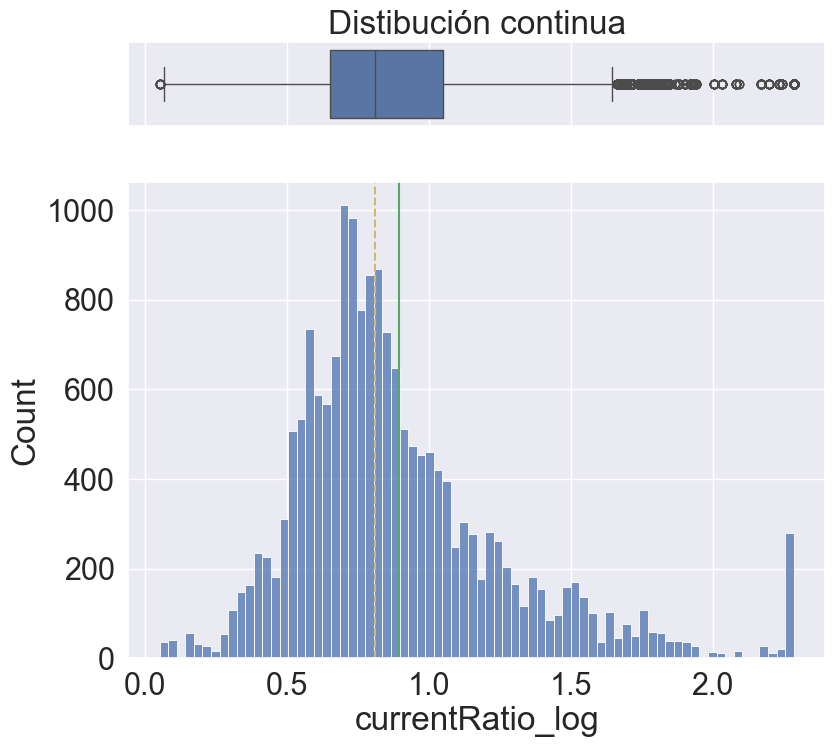

In [17]:
# Visualizar cambios
columna_a_graficar = 'currentRatio_log' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [18]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Return,17986.0,0.013535,0.088597,-0.342330,-0.039651,0.011671,0.061180,0.366073
Monthly_Variance,17986.0,0.007824,0.006138,-0.004304,0.003636,0.005954,0.009783,0.028225
Market_Covariance,17986.0,0.001638,0.001472,-0.003955,0.000641,0.001413,0.002374,0.007594
operatingMargins,17986.0,0.191854,0.140423,-0.359800,0.106500,0.177500,0.261300,0.741900
profitMargins,17986.0,0.136212,0.129816,-0.353200,0.067300,0.121600,0.197900,0.603100
ReturnOnAssets,17986.0,0.079475,0.077078,-0.227700,0.033100,0.063600,0.117400,0.388700
Revenue_YoY,17986.0,0.051128,0.104555,-0.264333,0.003011,0.045168,0.091254,0.356000
Revenue_QoQ,17986.0,0.000002,0.000016,-0.000056,0.000000,0.000000,0.000000,0.000020
EBITDA_YoY,17986.0,0.123711,0.340946,-0.793949,-0.017103,0.095189,0.241832,1.019722
EBITDA_QoQ,17986.0,0.000014,0.000106,-0.000267,0.000000,0.000000,0.000000,0.000163


# Variables Categoricas

In [19]:
df_cat_transformed = df_transformed_features.select_dtypes(exclude='number')

# Valores únicos
df_cat_transformed.nunique()

Sector        11
DateAdded    338
dtype: int64

In [20]:
# Convertir Sector a category
df_cat_transformed['Sector'] = df_cat_transformed['Sector'].astype('category')

# Valores unicos en Sector
df_cat_transformed['Sector'].value_counts()

Sector
Industrials              3123
InformationTechnology    2828
HealthCare               2200
ConsumerDiscretionary    1900
ConsumerStaples          1477
Financials               1268
RealEstate               1209
Utilities                1174
Materials                1025
CommunicationServices     925
Energy                    857
Name: count, dtype: int64

In [21]:
# Transformar DateAdded a datetime y convertir a YearsSinceAdded
df_cat_transformed['DateAdded'] = pd.to_datetime(df_cat_transformed['DateAdded'], errors='coerce')
df_cat_transformed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_cat_transformed['DateAdded']).dt.days / 365.25), 0)
df_cat_transformed.drop('DateAdded', axis=1, inplace=True)

In [22]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_cat_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17986 entries, 0 to 17985
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   MarketCap                   17986 non-null  float64 
 1   EnterpriseValue             17986 non-null  float64 
 2   PE_Trailing                 17986 non-null  float64 
 3   EnterpriseToEbitda          17986 non-null  float64 
 4   PriceToBook                 17986 non-null  float64 
 5   TotalAssets                 17986 non-null  float64 
 6   TotalRevenue                17986 non-null  float64 
 7   TotalEquity                 17986 non-null  float64 
 8   Date                        17986 non-null  object  
 9   Ticker                      17986 non-null  object  
 10  Close_log                   17986 non-null  float64 
 11  Sector                      17986 non-null  category
 12  YearsSinceAdded             17986 non-null  float64 
 13  Monthly_Return  

In [23]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")